In [3]:
"""
Stirling Cycle for Fermionic Systems (e.g. MATBG flat bands)
=============================================================
All energies in meV, temperatures in Kelvin.

The cycle has four strokes:
  1. Isothermal expansion   at T_h : ΔV₁ → ΔV₂   (W₁, Q_h1)
  2. Isochoric cooling      at ΔV₂ : T_h → T_c    (Q_c2)
  3. Isothermal compression at T_c : ΔV₂ → ΔV₁   (W₃, Q_c3)
  4. Isochoric heating      at ΔV₁ : T_c → T_h    (Q_h4)

Operational regimes (regime code):
  1 → Heat engine   (Q_hot > 0, Q_cold < 0, W_T > 0)
  2 → Refrigerator  (Q_hot < 0, Q_cold > 0, W_T < 0)
  3 → Heat pump     (Q_hot > 0, Q_cold < 0, W_T < 0)
  4 → Dissipator    (Q_hot < 0, Q_cold < 0, W_T < 0)
  0 → Undefined
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D

# ── Physical constant ─────────────────────────────────────────────────────────
KB = 8.617_333e-2   # Boltzmann constant [meV/K]


# ═════════════════════════════════════════════════════════════════════════════
# Thermodynamic quantities — single point (one ΔV, one T) → one scalar
# ═════════════════════════════════════════════════════════════════════════════

def free_energy_point(ens: np.ndarray, T: float) -> float:
    """F = -k_B T Σ_n ln(1 + exp(-ε_n / k_B T))"""
    kbT = KB * T
    ens = ens[~np.isnan(ens)]
    return float(-kbT * np.sum(np.log(1.0 + np.exp(-ens / kbT))))


def entropy_point(ens: np.ndarray, T: float, dT: float = 1e-6) -> float:
    """S = -∂F/∂T  via central finite difference."""
    return -(free_energy_point(ens, T + dT) - free_energy_point(ens, T - dT)) / (2.0 * dT)


def internal_energy_point(ens: np.ndarray, T: float, dT: float = 1e-6) -> float:
    """U = F + TS"""
    return free_energy_point(ens, T) + T * entropy_point(ens, T, dT)


# ── Helper: interpolate energy levels to an arbitrary dv, then compute F/S/U ─

def _thermo_at(Dv: np.ndarray, energies: np.ndarray, dv: float, T: float):
    """Interpolate energy levels to dv, return (F, S, U) at temperature T."""
    ens = np.array([np.interp(dv, Dv, energies[:, k])
                    for k in range(energies.shape[1])])
    F = free_energy_point(ens, T)
    S = entropy_point(ens, T)
    U = internal_energy_point(ens, T)
    return F, S, U


# ═════════════════════════════════════════════════════════════════════════════
# Stirling cycle — single parameter set (dv1, dv2, Tc, Th) → scalars
# ═════════════════════════════════════════════════════════════════════════════

def stirling_point(Dv, energies, dv1, dv2, Tc, Th):
    """
    Evaluate the full Stirling cycle for ONE parameter set.

    Parameters
    ----------
    Dv, energies : data arrays (for interpolation)
    dv1, dv2     : ΔV at start and mid-cycle [meV·m]
    Tc, Th       : cold and hot temperatures [K]

    Returns
    -------
    Q_hot, Q_cold, W_T : floats [meV]
    regime             : int (0–4, see module docstring)
    """
    F1h, S1h, U1h = _thermo_at(Dv, energies, dv1, Th)
    F1c, S1c, U1c = _thermo_at(Dv, energies, dv1, Tc)
    F2h, S2h, U2h = _thermo_at(Dv, energies, dv2, Th)
    F2c, S2c, U2c = _thermo_at(Dv, energies, dv2, Tc)

    # Stroke contributions
    W1   = -(F2h - F1h)            # isothermal expansion work
    Q_h1 =  Th * (S2h - S1h)      # isothermal expansion heat
    Q_c2 =  U2c - U2h             # isochoric cooling heat
    W3   = -(F1c - F2c)            # isothermal compression work
    Q_c3 =  Tc * (S1c - S2c)      # isothermal compression heat
    Q_h4 =  U1h - U1c             # isochoric heating heat

    Q_hot  = Q_h1 + Q_h4
    Q_cold = Q_c2 + Q_c3
    W_T    = W1   + W3

    # Classify regime
    if   Q_hot > 0 and Q_cold < 0 and W_T > 0: regime = 1
    elif Q_hot < 0 and Q_cold > 0 and W_T < 0: regime = 2
    elif Q_hot > 0 and Q_cold < 0 and W_T < 0: regime = 3
    elif Q_hot < 0 and Q_cold < 0 and W_T < 0: regime = 4
    else:                                        regime = 0

    return Q_hot, Q_cold, W_T, regime


# ═════════════════════════════════════════════════════════════════════════════
# Sweep ΔV₂ over the full grid (fixed dv1, Tc, Th)
# ═════════════════════════════════════════════════════════════════════════════

def stirling_sweep(Dv, energies, dv1, Tc, Th, plot=True):
    """
    Call stirling_point for every ΔV₂ in Dv, with fixed dv1, Tc, Th.

    Returns
    -------
    Q_hot_arr, Q_cold_arr, W_T_arr : np.ndarray, shape (N,)
    """
    results = [stirling_point(Dv, energies, dv1, dv2, Tc, Th) for dv2 in Dv]

    Q_hot_arr  = np.array([r[0] for r in results])
    Q_cold_arr = np.array([r[1] for r in results])
    W_T_arr    = np.array([r[2] for r in results])

    if plot:
        fig, axes = plt.subplots(3, 1, figsize=(9, 10), sharex=True)
        axes[0].plot(Dv, Q_hot_arr,  color="crimson",     lw=1.5)
        axes[0].set_ylabel(r"$Q_\mathrm{hot}$  (meV)",  fontsize=13)
        axes[0].set_title(
            rf"Stirling sweep: $\Delta V_1={dv1}$, $T_c={Tc}$ K, $T_h={Th}$ K",
            fontsize=13)
        axes[1].plot(Dv, Q_cold_arr, color="royalblue",   lw=1.5)
        axes[1].set_ylabel(r"$Q_\mathrm{cold}$  (meV)", fontsize=13)
        axes[2].plot(Dv, W_T_arr,    color="forestgreen", lw=1.5)
        axes[2].set_ylabel(r"$W_T$  (meV)",              fontsize=13)
        axes[2].set_xlabel(r"$\Delta V_2$  (meV·m)",     fontsize=13)
        for ax in axes:
            ax.axhline(0, color="gray", lw=0.6, ls="--")
            ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    return Q_hot_arr, Q_cold_arr, W_T_arr


# ═════════════════════════════════════════════════════════════════════════════
# Heatmap — 2-D grid over (ΔV₁, ΔV₂)
# ═════════════════════════════════════════════════════════════════════════════
"""
Stirling Cycle — W_T Heatmap
=============================
Plots total work W_T(ΔV₁, ΔV₂) over the full parameter grid,
with each cell evaluated via stirling_point.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D

KB = 8.617_333e-2   # Boltzmann constant [meV/K]


# ═════════════════════════════════════════════════════════════════════════════
# Thermodynamic quantities — single point → scalar
# ═════════════════════════════════════════════════════════════════════════════

def free_energy_point(ens: np.ndarray, T: float) -> float:
    """F = -k_B T Σ_n ln(1 + exp(-ε_n / k_B T))"""
    kbT = KB * T
    ens = ens[~np.isnan(ens)]
    return float(-kbT * np.sum(np.log(1.0 + np.exp(-ens / kbT))))


def entropy_point(ens: np.ndarray, T: float, dT: float = 1e-6) -> float:
    """S = -∂F/∂T  via central finite difference."""
    return -(free_energy_point(ens, T + dT) - free_energy_point(ens, T - dT)) / (2.0 * dT)


def internal_energy_point(ens: np.ndarray, T: float, dT: float = 1e-6) -> float:
    """U = F + TS"""
    return free_energy_point(ens, T) + T * entropy_point(ens, T, dT)


def _thermo_at(Dv, energies, dv, T):
    """Interpolate energy levels to dv, return (F, S, U) at temperature T."""
    ens = np.array([np.interp(dv, Dv, energies[:, k])
                    for k in range(energies.shape[1])])
    return (free_energy_point(ens, T),
            entropy_point(ens, T),
            internal_energy_point(ens, T))


# ═════════════════════════════════════════════════════════════════════════════
# Stirling cycle — single parameter set → scalars
# ═════════════════════════════════════════════════════════════════════════════

def stirling_point(Dv, energies, dv1, dv2, Tc, Th):
    """
    Evaluate the full Stirling cycle for ONE parameter set.

    Returns
    -------
    Q_hot, Q_cold, W_T : floats [meV]
    regime             : int  1=engine, 2=fridge, 3=heatpump, 4=dissipator, 0=undefined
    """
    F1h, S1h, U1h = _thermo_at(Dv, energies, dv1, Th)
    F1c, S1c, U1c = _thermo_at(Dv, energies, dv1, Tc)
    F2h, S2h, U2h = _thermo_at(Dv, energies, dv2, Th)
    F2c, S2c, U2c = _thermo_at(Dv, energies, dv2, Tc)

    W1   = -(F2h - F1h)
    Q_h1 =  Th * (S2h - S1h)
    Q_c2 =  U2c - U2h
    W3   = -(F1c - F2c)
    Q_c3 =  Tc * (S1c - S2c)
    Q_h4 =  U1h - U1c

    Q_hot  = Q_h1 + Q_h4
    Q_cold = Q_c2 + Q_c3
    W_T    = W1   + W3

    if   Q_hot > 0 and Q_cold < 0 and W_T > 0: regime = 1
    elif Q_hot < 0 and Q_cold > 0 and W_T < 0: regime = 2
    elif Q_hot > 0 and Q_cold < 0 and W_T < 0: regime = 3
    elif Q_hot < 0 and Q_cold < 0 and W_T < 0: regime = 4
    else:                                        regime = 0

    return Q_hot, Q_cold, W_T, regime


# ═════════════════════════════════════════════════════════════════════════════
# W_T heatmap
# ═════════════════════════════════════════════════════════════════════════════

def stirling_heatmap(Dv, energies, Tc, Th, n=80, save=False, save_path="3Fig3a.png"):
    """
    Compute and plot W_T(ΔV₁, ΔV₂) as a 2-D colour map.

    Each cell (i, j) is evaluated by calling stirling_point with
    (dv1=Dv_grid[i], dv2=Dv_grid[j], Tc, Th).

    Parameters
    ----------
    Dv, energies : data arrays
    Tc, Th       : cold / hot temperatures [K]
    n            : grid resolution (n × n)
    save         : save figure to disk
    save_path    : output filename

    Returns
    -------
    Dv_grid, W_T_masked, regime_map
    """
    Dv_grid   = np.linspace(Dv[0], Dv[-1], n)
    W_T_map   = np.full((n, n), np.nan)
    Q_hot_map = np.full((n, n), np.nan)
    Q_cold_map= np.full((n, n), np.nan)
    regime_map= np.zeros((n, n), dtype=int)

    for i, dv1 in enumerate(Dv_grid):
        for j, dv2 in enumerate(Dv_grid):
            Qh, Qc, W, reg = stirling_point(Dv, energies, dv1, dv2, Tc, Th)
            Q_hot_map[i, j]  = Qh
            Q_cold_map[i, j] = Qc
            W_T_map[i, j]    = W * 1000      # meV → μeV
            regime_map[i, j] = reg

    W_T_masked = np.where(regime_map > 0, W_T_map, np.nan)

    # ── Plot ──────────────────────────────────────────────────────────────────
    vmin = np.nanmin(W_T_masked)
    vmax = np.nanmax(W_T_masked)
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.pcolormesh(Dv_grid, Dv_grid, W_T_masked,
                       cmap="RdBu_r", norm=norm, shading="auto")

    cbar = plt.colorbar(im, ax=ax)
    cbar.ax.set_ylabel(r"$W_T$  ($\mu$eV)", fontsize=30, color="blue")
    cbar.ax.tick_params(labelsize=25)
    cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
    cbar.ax.axhline(y=0, color="black", linewidth=1, linestyle="-", alpha=0.5)

    cs_kw = dict(linewidths=2)
    ax.contour(Dv_grid, Dv_grid, W_T_map,    levels=[0], colors="black",  **cs_kw)
    ax.contour(Dv_grid, Dv_grid, Q_hot_map,  levels=[0], colors="crimson", linestyles="--", **cs_kw)
    ax.contour(Dv_grid, Dv_grid, Q_cold_map, levels=[0], colors="purple",  linestyles="--", **cs_kw)

    ax.legend(handles=[
        Line2D([0],[0], color="black",   lw=2, ls="-",  label=r"$W_T=0$"),
        Line2D([0],[0], color="crimson", lw=2, ls="--", label=r"$Q_\mathrm{hot}=0$"),
        Line2D([0],[0], color="purple",  lw=2, ls="--", label=r"$Q_\mathrm{cold}=0$"),
    ], fontsize=20, loc="upper center")

    ax.set_xlabel(r"$\Delta_{v2}$  (meV)", fontsize=40)
    ax.set_ylabel(r"$\Delta_{v1}$  (meV)", fontsize=40)
    ax.tick_params(axis="both", labelsize=30)

    plt.tight_layout()
    if save:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved to '{save_path}'")
    plt.show()

    return Dv_grid, W_T_masked, regime_map




In [2]:

# ═════════════════════════════════════════════════════════════════════════════
# COP / efficiency heatmap
# ═════════════════════════════════════════════════════════════════════════════

def cop_heatmap(Dv, energies, Tc, Th, n=80, save=False, save_path="3Fig3b.png",
                pump_cop_cap=50):
    """
    Build and plot performance metrics over the (ΔV₁, ΔV₂) grid.

    Each cell is evaluated by calling stirling_point(dv1, dv2, Tc, Th).
    The metric plotted depends on the operational regime:
      Engine      → η / η_Carnot
      Refrigerator → COP_RE / COP_Carnot
      Heat pump   → COP_CP  (capped at pump_cop_cap)

    Parameters
    ----------
    Dv, energies : data arrays
    Tc, Th       : cold / hot temperatures [K]
    n            : grid resolution (n × n)
    save         : save figure to disk
    save_path    : output filename
    pump_cop_cap : upper cap for heat-pump COP display (default 50)

    Returns
    -------
    Dv_grid, combined_map, regime_map, W_T_map, Q_hot_map, Q_cold_map,
    engine_values, refrigerator_values, coldpump_values
    """
    eta_c = 1.0 - Tc / Th
    COP_c = Tc / (Th - Tc)

    Dv_grid = np.linspace(Dv[0], Dv[-1], n)

    # Output arrays
    regime_map        = np.zeros((n, n), dtype=int)
    Q_cold_map        = np.full((n, n), np.nan)
    Q_hot_map         = np.full((n, n), np.nan)
    W_T_map           = np.full((n, n), np.nan)
    combined_map      = np.full((n, n), np.nan)
    engine_values     = np.full((n, n), np.nan)
    refrigerator_values = np.full((n, n), np.nan)
    coldpump_values   = np.full((n, n), np.nan)

    # ── Fill arrays ───────────────────────────────────────────────────────────
    print("Computing COP/η heatmap...")
    for i, dv1 in enumerate(Dv_grid):
        if i % max(1, n // 10) == 0:
            print(f"  row {i}/{n}")
        for j, dv2 in enumerate(Dv_grid):
            Qh, Qc, W, reg = stirling_point(Dv, energies, dv1, dv2, Tc, Th)

            Q_hot_map[i, j]  = Qh
            Q_cold_map[i, j] = Qc
            W_T_map[i, j]    = W
            regime_map[i, j] = reg

            if reg == 1:    # Heat engine
                val = (W / Qh) / eta_c
                engine_values[i, j]  = val
                combined_map[i, j]   = val

            elif reg == 2:  # Refrigerator
                val = (abs(Qc) / abs(W)) / COP_c
                refrigerator_values[i, j] = val
                combined_map[i, j]        = val

            elif reg == 3:  # Heat pump
                val = min(abs(Qc) / abs(W), pump_cop_cap)
                coldpump_values[i, j] = val
                combined_map[i, j]    = val

    # ── Build RGB image ───────────────────────────────────────────────────────
    rgb_image  = np.ones((n, n, 3))   # white for undefined regions
    plasma_cmap = plt.cm.plasma
    cool_cmap   = plt.cm.cool
    hot_cmap    = plt.cm.hot_r

    colorbar_info = {}

    engine_mask = (regime_map == 1)
    ref_mask    = (regime_map == 2)
    pump_mask   = (regime_map == 3)

    if np.any(engine_mask):
        vmax = np.nanmax(engine_values[engine_mask])
        norm = plt.Normalize(vmin=0, vmax=vmax)
        rgb_image[engine_mask] = plasma_cmap(norm(engine_values[engine_mask]))[:, :3]
        colorbar_info["engine"] = dict(vmin=0, vmax=vmax, cmap=plasma_cmap,
            label=r"HE: $\eta_{\mathrm{HE}}/\eta_{\mathrm{c}}$")
        print(f"Heat engine η/η_c range: 0 → {vmax:.3f}")

    if np.any(ref_mask):
        vmax = np.nanmax(refrigerator_values[ref_mask])
        norm = plt.Normalize(vmin=0, vmax=vmax)
        rgb_image[ref_mask] = cool_cmap(norm(refrigerator_values[ref_mask]))[:, :3]
        colorbar_info["refrigerator"] = dict(vmin=0, vmax=vmax, cmap=cool_cmap,
            label=r"RE: $\mathrm{COP_{RE}}/\mathrm{COP_{c}}$")
        print(f"Refrigerator COP/COP_c range: 0 → {vmax:.3f}")

    if np.any(pump_mask):
        norm = plt.Normalize(vmin=0, vmax=pump_cop_cap)
        rgb_image[pump_mask] = hot_cmap(norm(coldpump_values[pump_mask]))[:, :3]
        colorbar_info["coldpump"] = dict(vmin=0, vmax=pump_cop_cap, cmap=hot_cmap,
            label=r"CP: $\mathrm{COP_{CP}}$")
        print(f"Heat pump COP range: 0 → {pump_cop_cap} (capped)")

    # ── Figure layout ─────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(10, 8))
    ax  = fig.add_axes([0.10, 0.10, 0.60, 0.80])

    cbar_x      = 0.73
    cbar_w      = 0.03
    cbar_h      = 0.24
    cbar_gap    = 0.05
    total_h     = 3 * cbar_h + 2 * cbar_gap
    cbar_y0     = (0.80 - total_h) / 2 + 0.05

    cbar_axes = {
        "engine":       fig.add_axes([cbar_x, cbar_y0 + 2*(cbar_h + cbar_gap), cbar_w, cbar_h]),
        "refrigerator": fig.add_axes([cbar_x, cbar_y0 +   (cbar_h + cbar_gap), cbar_w, cbar_h]),
        "coldpump":     fig.add_axes([cbar_x, cbar_y0,                          cbar_w, cbar_h]),
    }

    # ── Main image ────────────────────────────────────────────────────────────
    ax.imshow(rgb_image,
              extent=[Dv_grid[0], Dv_grid[-1], Dv_grid[0], Dv_grid[-1]],
              origin="lower", aspect="equal")

    cs_kw = dict(linewidths=2)
    ax.contour(Dv_grid, Dv_grid, W_T_map,    levels=[0], colors="white",  linestyles="--", **cs_kw)
    ax.contour(Dv_grid, Dv_grid, Q_hot_map,  levels=[0], colors="red",    linestyles="--", **cs_kw)
    ax.contour(Dv_grid, Dv_grid, Q_cold_map, levels=[0], colors="blue",   linestyles="--", **cs_kw)

    ax.legend(handles=[
        Line2D([0],[0], color="white", lw=2, ls="--", label=r"$W_T = 0$"),
        Line2D([0],[0], color="red",   lw=2, ls="--", label=r"$Q_{\mathrm{hot}} = 0$"),
        Line2D([0],[0], color="blue",  lw=2, ls="--", label=r"$Q_{\mathrm{cold}} = 0$"),
    ], fontsize=20, loc="upper center")

    ax.set_xlabel(r"$\Delta_{v2}$  (meV)", fontsize=40)
    ax.set_ylabel(r"$\Delta_{v1}$  (meV)", fontsize=40)
    ax.tick_params(axis="both", labelsize=30)

    # ── Colorbars ─────────────────────────────────────────────────────────────
    def _add_colorbar(cax, info):
        sm = plt.cm.ScalarMappable(
            cmap=info["cmap"],
            norm=plt.Normalize(vmin=info["vmin"], vmax=info["vmax"]))
        sm.set_array([])
        cbar = plt.colorbar(sm, cax=cax, orientation="vertical")
        cbar.set_label(info["label"], fontsize=20, color="blue")
        cbar.ax.tick_params(labelsize=20)
        ticks = np.linspace(info["vmin"], info["vmax"], 4)
        cbar.set_ticks(ticks)
        cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))

    for key in ("engine", "refrigerator", "coldpump"):
        if key in colorbar_info:
            _add_colorbar(cbar_axes[key], colorbar_info[key])

    plt.tight_layout()
    if save:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved to '{save_path}'")
    plt.show()

    return (Dv_grid, combined_map, regime_map, W_T_map, Q_hot_map, Q_cold_map,
            engine_values, refrigerator_values, coldpump_values)




Saved to '3Fig3a.png'


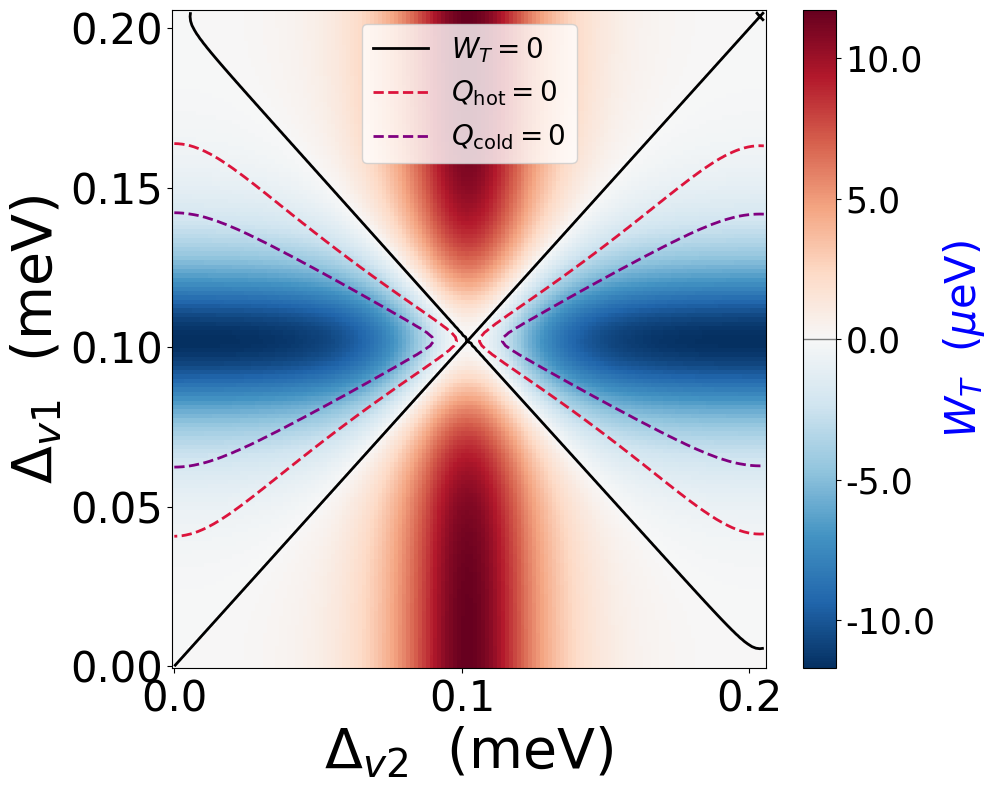

Computing COP/η heatmap...
  row 0/1000
  row 100/1000
  row 200/1000
  row 300/1000
  row 400/1000
  row 500/1000
  row 600/1000
  row 700/1000
  row 800/1000
  row 900/1000
Heat engine η/η_c range: 0 → 0.990
Refrigerator COP/COP_c range: 0 → 0.954
Heat pump COP range: 0 → 50 (capped)


/var/folders/j9/mv8r31ws7gd9xn1rn1c8gjnr0000gn/T/ipykernel_21150/1889556693.py:162: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved to '3Fig3b.png'


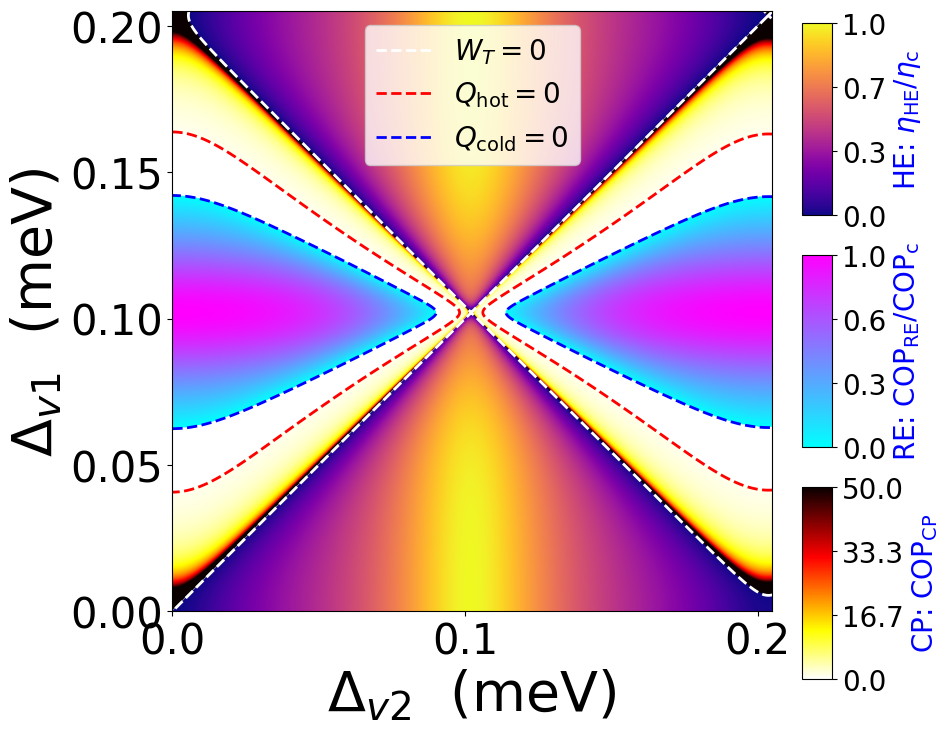

In [4]:

data     = np.loadtxt("ABS_MATBG_phi0_tillDv0205.dat", skiprows=1)
Dv       = data[:, 0]
energies = data[:, 1:9]

Dv_grid, WT_masked, regime_map = stirling_heatmap(Dv, energies, Tc=0.05, Th=0.10, n=150, save=False)
results = cop_heatmap(Dv, energies, Tc=0.05, Th=0.10, n=1000,save=False, save_path="3Fig3b.png")
Dv_grid, combined_map, regime_map = results[0], results[1], results[2]